In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
single_layer_file = "/Users/harukanarita/Desktop/Projects/fl_bar_processing/notebook/output/single_layer_props_with_gt.csv"
df_single = pd.read_csv(single_layer_file)
df_single

,c1_intensity_median,c1_intensity_mean,c1_intensity_max,c1_intensity_min,c1_intensity_center_5pixel,c2_intensity_median,c2_intensity_mean,c2_intensity_max,c2_intensity_min,c2_intensity_center_5pixel,c3_intensity_median,c3_intensity_mean,c3_intensity_max,c3_intensity_min,c3_intensity_center_5pixel,bar_id,area,layer_id,field_name,GroundTruth
0,107.0,107.199516,121,93,107.6,103.0,103.378476,121,87,102.4,2423.5,3115.194075,7998,240,5924.8,3,1022,Layer 2,A - 1_fld-2,1
1,107.0,107.166667,126,88,106.8,104.0,103.950828,118,86,106.0,2600.5,4191.283126,12854,265,10057.0,4,1170,Layer 2,A - 1_fld-2,1
2,107.0,107.282249,122,92,109.2,104.0,103.630178,116,86,104.4,2500.5,3334.929586,8624,260,7362.0,5,1067,Layer 2,A - 1_fld-2,1
3,107.0,106.536802,120,91,111.0,104.0,103.715102,121,85,110.2,2346.5,2797.446066,6602,277,5287.4,7,1044,Layer 2,A - 1_fld-2,1
4,107.0,106.856275,122,89,108.8,104.0,103.747470,117,78,102.2,3020.0,4717.412449,13524,258,10627.8,10,1287,Layer 2,A - 1_fld-2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10255,6384.5,8144.442473,20852,380,16291.8,2557.5,3327.631720,8611,159,6712.6,3220.5,4188.342473,10730,261,8463.0,164,1193,Layer 2,A - 9_fld-9,9
10256,10545.0,12890.975385,32587,434,31461.4,4248.0,5174.456000,13147,181,12958.0,5316.0,6695.373538,17588,259,17334.2,165,1207,Layer 2,A - 9_fld-9,9
10257,11157.0,10963.268957,22226,388,20417.6,3780.0,3873.802981,7671,166,7194.4,4110.0,4193.979909,8455,230,7618.0,167,1179,Layer 2,A - 9_fld-9,9
10258,15440.0,15798.752641,35042,404,30820.4,7531.0,7664.989434,16696,205,15544.0,8367.0,8652.315103,19706,283,17748.6,169,1377,Layer 2,A - 9_fld-9,9


In [3]:
colors = [
        '#1f77b4',  # Blue
        '#ff7f0e',  # Orange
        '#2ca02c',  # Green
        '#d62728',  # Red
        '#9467bd',  # Purple
        '#8c564b',  # Brown
        '#e377c2',  # Pink
        '#bcbd22',  # Olive
        '#17becf'   # Cyan
    ]

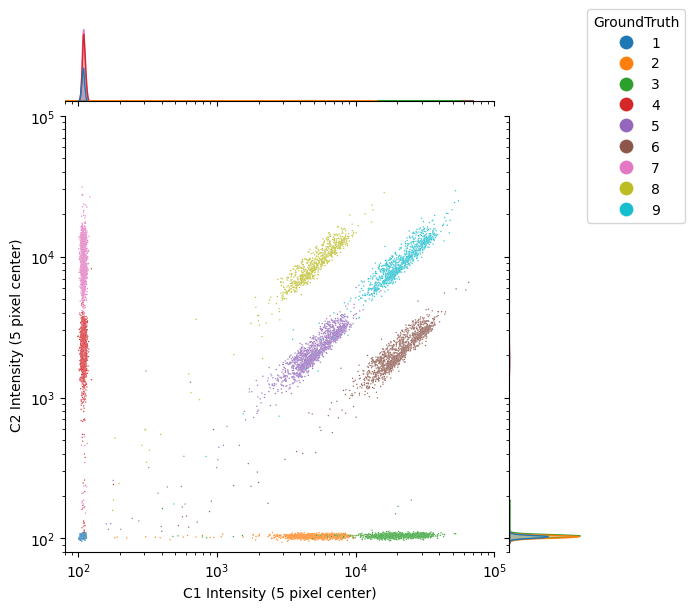

In [4]:
import seaborn as sns

g = sns.jointplot(
    data=df_single, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='GroundTruth',
    palette=colors,
    s=1)

g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_yscale('linear')
g.ax_marg_y.set_xscale('linear')

g.set_axis_labels('C1 Intensity (5 pixel center)', 'C2 Intensity (5 pixel center)')

g.ax_joint.set_xlim(8e1, 1e5)
g.ax_joint.set_ylim(8e1, 1e5)
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(
    handles=handles, 
    labels=labels, 
    loc='center left', 
    bbox_to_anchor=(1.2, 1), 
    title='GroundTruth', 
    scatterpoints=3, 
    markerscale=10
)

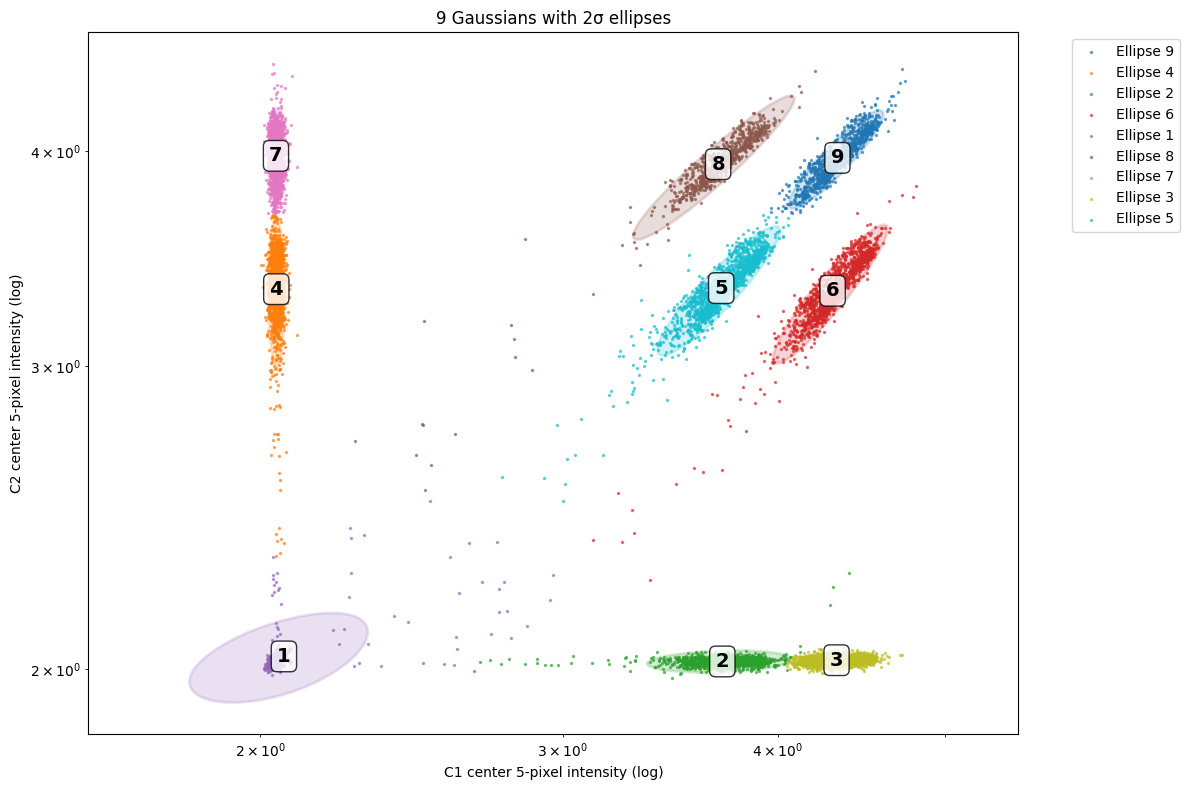

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal


def fit_gaussians(x_data, y_data, n_components=9):
    data = np.column_stack([x_data, y_data])
    gmm = GaussianMixture(n_components=n_components, random_state=1235)
    gmm.fit(data)
    return gmm


def assign_ellipse_ids(gmm):
    """
    789
    456
    123
    """
    means = gmm.means_
    x_sorted_indices = np.argsort(means[:, 0])
    y_sorted_indices = np.argsort(means[:, 1])
    x_orders = np.empty_like(x_sorted_indices)
    y_orders = np.empty_like(y_sorted_indices)
    x_orders[x_sorted_indices] = np.arange(len(means))
    y_orders[y_sorted_indices] = np.arange(len(means))

    x_grid = x_orders // 3
    y_grid = y_orders // 3
    return y_grid * 3 + x_grid + 1


def classify_points_to_ellipses(x_data, y_data, gmm, ellipse_ids, n_sigma=2):
    data = np.column_stack([x_data, y_data])

    probabilities = gmm.predict_proba(data)
    best_gaussian_indices = np.argmax(probabilities, axis=1)
    point_ellipse_ids = ellipse_ids[best_gaussian_indices]

    return point_ellipse_ids, probabilities


def plot_gaussians_with_ellipses(
    x_data, y_data, gmm, ellipse_ids, point_ellipse_ids, n_sigma=2
):
    plt.figure(figsize=(12, 8))

    ellipse_colors = [
        "#1f77b4",  # Blue
        "#ff7f0e",  # Orange
        "#2ca02c",  # Green
        "#d62728",  # Red
        "#9467bd",  # Purple
        "#8c564b",  # Brown
        "#e377c2",  # Pink
        "#bcbd22",  # Olive
        "#17becf",  # Cyan
    ]

    for i, ellipse_id in enumerate(ellipse_ids):
        mask = point_ellipse_ids == ellipse_id
        if np.any(mask):
            plt.scatter(
                x_data[mask],
                y_data[mask],
                alpha=0.6,
                s=2,
                color=ellipse_colors[i],
                label=f"Ellipse {ellipse_id}",
            )

    for i, (mean, cov, ellipse_id) in enumerate(
        zip(gmm.means_, gmm.covariances_, ellipse_ids)
    ):
        plt.plot(
            mean[0],
            mean[1],
            "x",
            color=ellipse_colors[i],
            markersize=12,
            markeredgewidth=3,
        )

        eigenvals, eigenvecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        width = 2 * n_sigma * np.sqrt(eigenvals[0])
        height = 2 * n_sigma * np.sqrt(eigenvals[1])

        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            facecolor=ellipse_colors[i],
            alpha=0.2,
            edgecolor=ellipse_colors[i],
            linewidth=2,
        )
        plt.gca().add_patch(ellipse)

        plt.text(
            mean[0],
            mean[1],
            str(ellipse_id),
            fontsize=14,
            fontweight="bold",
            ha="center",
            va="center",
            color="black",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

    plt.xlabel("C1 center 5-pixel intensity (log)")
    plt.ylabel("C2 center 5-pixel intensity (log)")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"{len(gmm.means_)} Gaussians with {n_sigma}σ ellipses")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


x_data = np.log10(df_single["c1_intensity_center_5pixel"].values + 1)
y_data = np.log10(df_single["c2_intensity_center_5pixel"].values + 1)

gmm = fit_gaussians(x_data, y_data, n_components=9)
ellipse_ids = assign_ellipse_ids(gmm)

point_ellipse_ids, probabilities = classify_points_to_ellipses(
    x_data, y_data, gmm, ellipse_ids, n_sigma=2
)

df_single.loc[:, "ellipse_id"] = point_ellipse_ids
for k in range(1, 10):
    df_single.loc[:, f"probabilities_{k}"] = probabilities[:, k - 1]

plot_gaussians_with_ellipses(
    x_data, y_data, gmm, ellipse_ids, point_ellipse_ids, n_sigma=2
)

P(Z=k|x) = (π_k × N(x|μ_k, σ_k²)) / Σ_j(π_j × N(x|μ_j, σ_j²))

In [54]:
def set_confidence(row):
    row["confidence"] = np.max([row[f'probabilities_{k}'] for k in range(1, 10)])
    row["is_correct"] = row["ellipse_id"] == row["GroundTruth"]
    return row

In [55]:
df_single = (
    df_single
    .apply(set_confidence, axis=1)
)

In [56]:
df_single

,c1_intensity_median,c1_intensity_mean,c1_intensity_max,c1_intensity_min,c1_intensity_center_5pixel,c2_intensity_median,c2_intensity_mean,c2_intensity_max,c2_intensity_min,c2_intensity_center_5pixel,...,probabilities_2,probabilities_3,probabilities_4,probabilities_5,probabilities_6,probabilities_7,probabilities_8,probabilities_9,confidence,is_correct
0,107.0,107.199516,121,93,107.6,103.0,103.378476,121,87,102.4,...,3.066402e-14,7.058381e-20,2.541239e-73,1.000000e+00,1.404128e-27,6.521339e-50,5.222709e-73,4.509491e-28,1.000000,True
1,107.0,107.166667,126,88,106.8,104.0,103.950828,118,86,106.0,...,4.730849e-14,7.276361e-21,3.884949e-75,1.000000e+00,1.120602e-26,3.048506e-49,1.118205e-75,1.572226e-28,1.000000,True
2,107.0,107.282249,122,92,109.2,104.0,103.630178,116,86,104.4,...,6.402834e-14,3.450614e-20,2.271481e-73,1.000000e+00,2.464032e-27,1.901903e-49,7.279998e-74,6.126866e-28,1.000000,True
3,107.0,106.536802,120,91,111.0,104.0,103.715102,121,85,110.2,...,2.166871e-13,5.332454e-22,9.503854e-75,1.000000e+00,2.824729e-26,2.351788e-48,1.821034e-78,4.773705e-28,1.000000,True
4,107.0,106.856275,122,89,108.8,104.0,103.747470,117,78,102.2,...,3.950014e-14,1.000633e-19,1.120414e-72,1.000000e+00,8.837126e-28,6.698198e-50,1.367697e-72,7.875733e-28,1.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10255,6384.5,8144.442473,20852,380,16291.8,2557.5,3327.631720,8611,159,6712.6,...,0.000000e+00,0.000000e+00,4.294894e-25,4.825972e-189,1.996511e-24,0.000000e+00,0.000000e+00,5.172144e-03,0.994828,True
10256,10545.0,12890.975385,32587,434,31461.4,4248.0,5174.456000,13147,181,12958.0,...,0.000000e+00,0.000000e+00,1.781045e-28,1.765256e-253,1.896634e-24,0.000000e+00,0.000000e+00,8.243866e-07,0.999999,True
10257,11157.0,10963.268957,22226,388,20417.6,3780.0,3873.802981,7671,166,7194.4,...,0.000000e+00,0.000000e+00,3.018112e-20,1.801732e-195,2.139590e-29,0.000000e+00,0.000000e+00,2.060205e-03,0.997940,True
10258,15440.0,15798.752641,35042,404,30820.4,7531.0,7664.989434,16696,205,15544.0,...,0.000000e+00,0.000000e+00,4.676062e-36,3.356241e-272,7.523802e-18,0.000000e+00,0.000000e+00,1.155677e-07,1.000000,True


In [57]:
df_single.to_csv("output/single_layer_props_with_gmm_probs.csv", index=False)

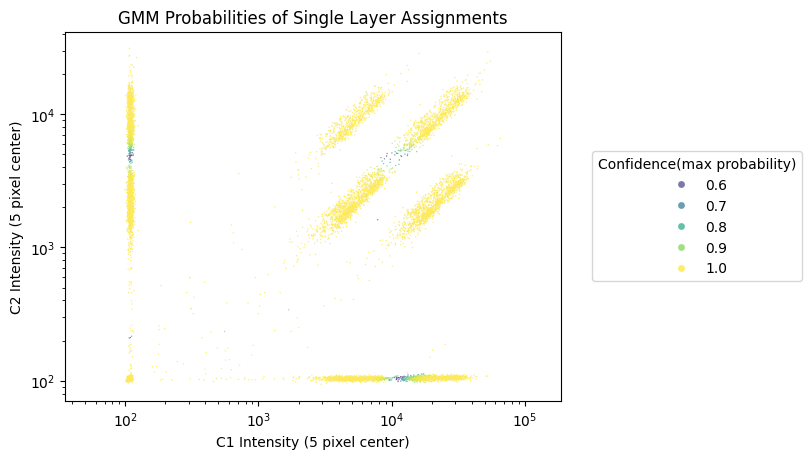

In [58]:
sns.scatterplot(
    data=df_single, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='confidence',
    palette='viridis',
    alpha=0.7,
    s=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('C1 Intensity (5 pixel center)')
plt.ylabel('C2 Intensity (5 pixel center)')
plt.title('GMM Probabilities of Single Layer Assignments')
plt.axis('equal')

plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), 
    title='Confidence(max probability)', 
    scatterpoints=1, 
    markerscale=5
)


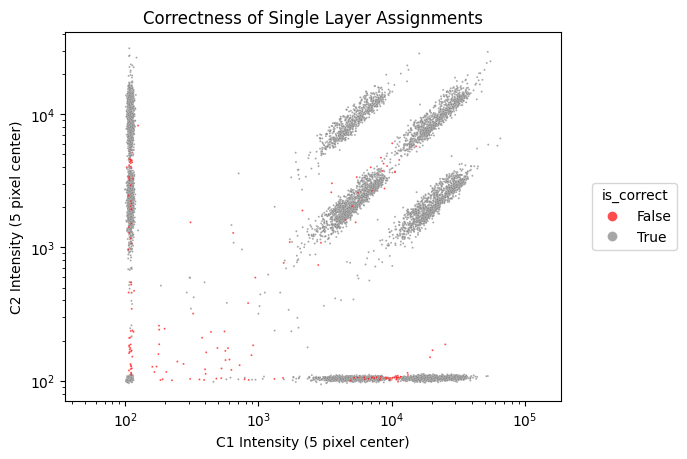

In [59]:
sns.scatterplot(
    data=df_single, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='is_correct',
    palette={True: 'gray', False: 'red'},
    alpha=0.7,
    s=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('C1 Intensity (5 pixel center)')
plt.ylabel('C2 Intensity (5 pixel center)')
plt.title('Correctness of Single Layer Assignments')
plt.axis('equal')

plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), 
    title='is_correct', 
    scatterpoints=1, 
    markerscale=5
)


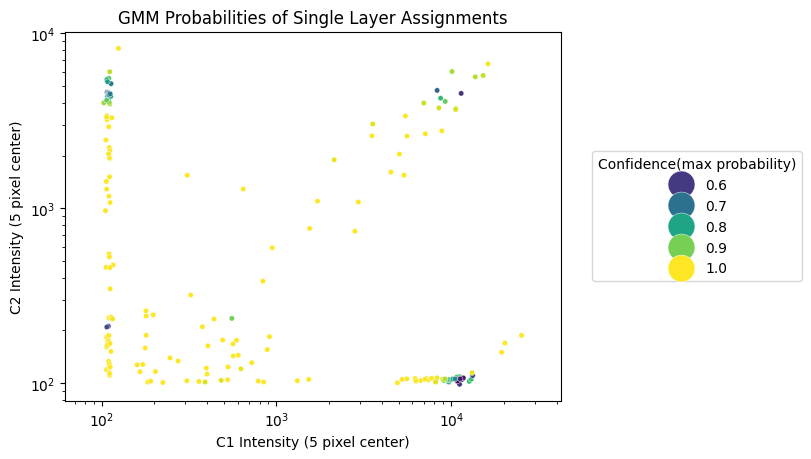

In [75]:
sns.scatterplot(
    data=df_single[df_single['is_correct'] == False], 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='confidence',
    palette='viridis',
    s=15)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('C1 Intensity (5 pixel center)')
plt.ylabel('C2 Intensity (5 pixel center)')
plt.title('GMM Probabilities of Single Layer Assignments')
plt.axis('equal')

plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), 
    title='Confidence(max probability)', 
    scatterpoints=1, 
    markerscale=5
)


In [61]:
df_single[df_single['is_correct'] == False]

,c1_intensity_median,c1_intensity_mean,c1_intensity_max,c1_intensity_min,c1_intensity_center_5pixel,c2_intensity_median,c2_intensity_mean,c2_intensity_max,c2_intensity_min,c2_intensity_center_5pixel,...,probabilities_2,probabilities_3,probabilities_4,probabilities_5,probabilities_6,probabilities_7,probabilities_8,probabilities_9,confidence,is_correct
599,2306.5,4153.372914,15180,163,12760.4,103.0,102.548780,117,91,103.6,...,0.000000e+00,1.469768e-01,2.811502e-91,1.534138e-89,0.000000e+00,0.000000e+00,8.530232e-01,2.037416e-187,0.853023,False
637,2252.0,3882.630805,13603,196,12678.2,102.0,102.188080,114,91,102.0,...,0.000000e+00,1.439859e-01,7.489006e-92,7.653972e-90,0.000000e+00,0.000000e+00,8.560141e-01,3.125374e-188,0.856014,False
714,393.5,439.579156,923,190,390.8,101.0,100.668865,119,81,101.2,...,0.000000e+00,2.722467e-02,8.651543e-20,9.727753e-01,2.061430e-58,0.000000e+00,1.218389e-34,4.786256e-14,0.972775,False
971,682.5,1640.598022,6787,138,360.6,102.0,101.671763,121,78,102.0,...,0.000000e+00,8.855242e-04,1.513343e-22,9.991145e-01,1.851401e-55,0.000000e+00,1.804741e-37,3.923000e-14,0.999114,False
1008,201.0,393.421649,1557,120,224.0,102.0,101.696558,119,79,100.6,...,6.182607e-165,9.683920e-11,1.990359e-39,1.000000e+00,2.219443e-42,9.389149e-215,3.343671e-51,4.721940e-17,1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10110,6810.5,7701.833553,17763,379,7108.6,2932.5,3485.215789,8275,160,2663.6,...,0.000000e+00,0.000000e+00,6.525201e-20,4.733128e-115,2.691808e-29,0.000000e+00,0.000000e+00,9.997845e-01,0.999784,False
10113,563.0,4684.901558,24511,337,8832.0,238.0,2114.509679,11096,150,2768.0,...,0.000000e+00,0.000000e+00,4.407883e-14,9.897803e-118,6.509987e-35,0.000000e+00,0.000000e+00,9.996731e-01,0.999673,False
10125,5234.0,7109.392657,18086,372,3519.8,2326.0,3002.726198,7549,155,2592.0,...,0.000000e+00,0.000000e+00,4.761749e-42,8.731469e-109,1.400919e-07,0.000000e+00,0.000000e+00,9.999905e-01,0.999990,False
10147,3701.0,6488.682771,19002,347,10587.6,1571.5,2731.277575,8004,149,3667.4,...,0.000000e+00,0.000000e+00,2.675330e-17,3.697742e-138,1.497229e-30,0.000000e+00,0.000000e+00,9.720952e-01,0.972095,False


In [66]:
def get_recovery_accuracy_curve(dfs:list, fig_titles:list):
    plt.figure(figsize=(6, 6))
    for df, fig_title in zip(dfs, fig_titles):
        confidences = df["confidence"].values
        is_correct = df["is_correct"].values

        thresholds = np.arange(0.1, 1.0, 0.05)  # 0.1, 0.15, 0.20, ..., 0.95
        recoveries = []
        accuracies = []

        for threshold in thresholds:
            above_threshold = confidences >= threshold
            recovery = np.sum(above_threshold) / len(confidences)
            
            correct_predictions = is_correct[above_threshold]
            accuracy = np.sum(correct_predictions) / np.sum(above_threshold)
            
            recoveries.append(recovery)
            accuracies.append(accuracy)

        recoveries = np.array(recoveries)
        accuracies = np.array(accuracies)

        plt.plot(recoveries, accuracies, linewidth=2, label=fig_title)
        plt.xlabel('Recovery')
        plt.ylabel('Accuracy')
        plt.title(f'Confidence-Recovery Curve')
        plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()


In [67]:
df_single_posterior = pd.read_csv("output/single_layer_props_with_posterior.csv")

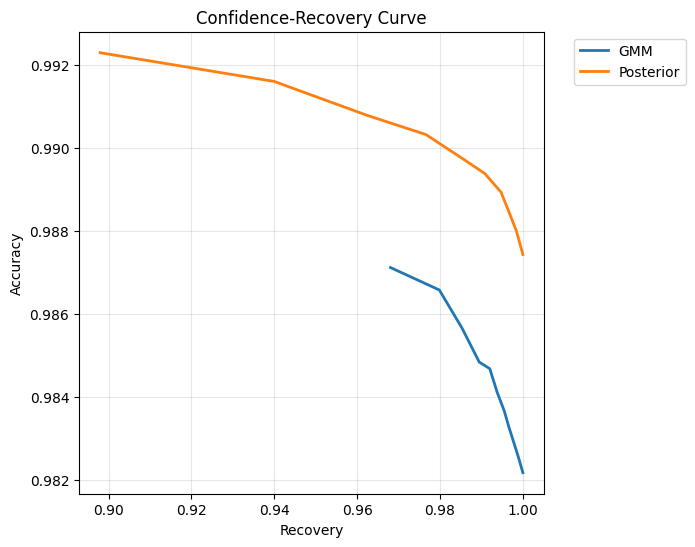

In [68]:
get_recovery_accuracy_curve([df_single, df_single_posterior], ["GMM", "Posterior"])

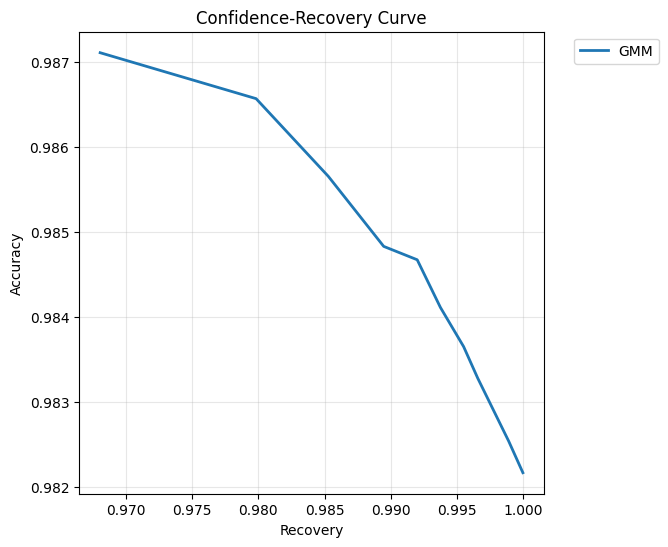

In [69]:
get_recovery_accuracy_curve([df_single], ["GMM"])